# 가상화폐 가격 변동 전조 신호 탐색

## 0. 주제
5개 대형 암호화폐(BTC, ETH, BNB, SOL, XRP)의 시세 데이터와 이들을 다룬 전세계 뉴스 보도량·논조 데이터를 함께 수집하여, 가격이 크게 움직이기 전에 공통적으로 관찰되는 신호가 있는지 살펴본다.

## 1. 분석 질문
> **"코인 가격이 상승·하락·횡보할 때, 사전에 공통적으로 나타나는 시장 지표나 뉴스 패턴이 있는가? 그 패턴은 특정 방향에만 해당되는가, 아니면 '큰 변동' 자체에 따라오는 것인가? 그리고 뉴스 보도량·논조는 가격 변동과 관련이 있는가?"**

가격의 다음 움직임을 **상승·횡보·하락 세 그룹**으로 나누고, 단기(24시간)와 장기(7일) 두 타임프레임으로 나누어 본다. 여기에 더해, 같은 기간 해당 코인을 다룬 전세계 뉴스의 보도량과 논조(긍정/부정)를 별도로 수집해 가격 변동과 함께 살펴본다.

필요 컬럼: 시장 특징 7개(`거래량비율`, `모멘텀`, `변동성(ATR)`, `RSI`, `이동평균 이격도`, `윗꼬리 비율`, `연속 상승 횟수`) + 뉴스 특징 2개(`보도량`, `평균 논조`).

## 2. 수집 대상
- **시세**: 
  - **출처**: Binance 공개 시세 API `https://api.binance.com/api/v3/klines` (공식 공개 API, 로그인·인증키 불필요, robots.txt 대상이 아닌 공개 데이터 엔드포인트)
  - **대상 심볼**: 비트코인, 이더리움, 바이낸스코인, 솔라나, 리플
  - **주기**: 4시간봉, 상장 시점부터 전체 기간
    - 트레이더들이 실무에서 가장 많이 참고하는 15분봉과 4시간봉 중, 15분봉은 장중 진입·청산 타이밍을 잡는 데는 유용하지만, 데이터량이 과도하게 많아지고, 노이즈가 많아 방향 판별이 어려우므로, 4시간봉을 선택했다.
- **뉴스**: GDELT Project의 BigQuery 공개 데이터셋 `gdelt-bq.gdeltv2.gkg`에서 일별 보도량·논조를 가져온다. GDELT는 전 세계 뉴스 매체를 언어·국가 무관하게 통합 색인하는 오픈 데이터 플랫폼(한국의 '빅카인즈'와 같은 성격의 해외 뉴스 빅데이터 플랫폼)으로, 국내 코인 도입 시점과 해외 상장·거래 시점이 달라 추가적인 이상치가 발생할 수 있는 문제를 방지하고자 글로벌 매체를 통해 우회한다. 2017~현재 전체 기간을 한 번에 집계하는 대량 조회이므로 실시간 소량 조회용 REST API 대신 BigQuery 공개 데이터셋을 사용한다.
- **개인정보/로그인 이슈**: 없음. **이용 목적**: 학습용 개인 과제.

In [1]:
import json
import time
import urllib.request

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 3. 데이터 수집

### 3-1. 뉴스 데이터 수집 — GDELT BigQuery 공개 데이터셋


각 코인명으로 전체 기간(2017-01-01 ~ anchor)의 **일별 보도량**과 **일별 평균 논조 데이터**를 모은다.

GDELT는 실시간 소량 조회용 REST API(`doc/doc`)와, 이번처럼 여러 해에 걸친 전체 기간을 한 번에 집계하는 대량 조회용 **BigQuery 공개 데이터셋**(`gdelt-bq.gdeltv2.gkg`)을 함께 제공하며, 본 작업은 후자에 해당하므로 BigQuery를 사용한다 — 참여 매체·기사 수 자체가 방대한 GDELT 특성상, 다년간 데이터를 API 호출 단위로 페이지네이션하며 받는 것보다 SQL로 일괄적 집계하는 쪽이 훨씬 안정적이고 빠르다. BigQuery는 컬럼형 저장구조라 쿼리에서 실제로 참조하는 컬럼만큼만 처리·과금되며(이번 쿼리는 전체 테이블 중 4개 컬럼만 사용해 처리량 676GB로, 무료 한도 월 1TB 이내), 아래 SQL을 BigQuery 콘솔에서 한 번 실행해 결과를 `raw_news_daily.csv`로 저장해두고 이 노트북에서는 그 결과를 불러와 사용한다.

In [34]:
# ```sql
# WITH gkg AS (
#   SELECT
#     PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS pub_date,
#     LOWER(CONCAT(IFNULL(V2Organizations, ''), ' ', IFNULL(AllNames, ''))) AS names_text,
#     SAFE_CAST(SPLIT(V2Tone, ',')[OFFSET(0)] AS FLOAT64) AS tone
#   FROM `gdelt-bq.gdeltv2.gkg`
#   WHERE DATE >= 20170101000000 AND DATE < 20260724000000
# ),
# tagged AS (
#   SELECT pub_date, tone, 'BTCUSDT' AS symbol FROM gkg WHERE REGEXP_CONTAINS(names_text, r'bitcoin')
#   UNION ALL
#   SELECT pub_date, tone, 'ETHUSDT' AS symbol FROM gkg WHERE REGEXP_CONTAINS(names_text, r'ethereum')
#   UNION ALL
#   SELECT pub_date, tone, 'BNBUSDT' AS symbol FROM gkg WHERE REGEXP_CONTAINS(names_text, r'binance coin')
#   UNION ALL
#   SELECT pub_date, tone, 'SOLUSDT' AS symbol FROM gkg WHERE REGEXP_CONTAINS(names_text, r'solana')
#   UNION ALL
#   SELECT pub_date, tone, 'XRPUSDT' AS symbol FROM gkg WHERE REGEXP_CONTAINS(names_text, r'\bxrp\b')
# )
# SELECT symbol, pub_date AS date, COUNT(*) AS news_volume, AVG(tone) AS news_tone
# FROM tagged
# GROUP BY symbol, pub_date
# ORDER BY symbol, pub_date;
# ```

# 본 코드를 노트북에서 실행 시 상당한 시간이 소요될 수 있으며, API 과다 요청으로 인한 접근 차단 등의 문제가 발생할 수 있어 해쉬태그 처리하고 참고용으로만 본다.
# 각 코인의 검색어 매핑은 아래와 같다 (동명이의어를 줄이기 위해 BNB만 구문 검색 사용).


In [35]:
GDELT_QUERIES = {
    "BTCUSDT": "bitcoin",
    "ETHUSDT": "ethereum",
    "BNBUSDT": '"binance coin"',
    "SOLUSDT": "solana",
    "XRPUSDT": "xrp",
}

news_df = pd.read_csv("raw_news_daily.csv")
news_df["date"] = pd.to_datetime(news_df["date"])
print(f"뉴스 데이터 로드 완료: raw_news_daily.csv ({len(news_df)}행)")
for symbol, query in GDELT_QUERIES.items():
    n = (news_df["symbol"] == symbol).sum()
    print(f"  {symbol} ({query}): {n}일분")


뉴스 데이터 로드 완료: raw_news_daily.csv (13085행)
  BTCUSDT (bitcoin): 3472일분
  ETHUSDT (ethereum): 3439일분
  BNBUSDT ("binance coin"): 2398일분
  SOLUSDT (solana): 3457일분
  XRPUSDT (xrp): 319일분


#### 논조(tone) 판단 기준 — GDELT `V2Tone` 필드

`news_tone`은 자체적으로 분석을 수행하지 않고, GDELT가 기사 원문에 대해 이미 계산해 제공하는 **`V2Tone`** 필드 값을 그대로 차용한다. `V2Tone`은 콤마로 구분된 7개 숫자로 구성되고, 위 SQL의 `SPLIT(V2Tone, ',')[OFFSET(0)]`은 이 중 **첫 번째 값**만 뽑은 것이다.

| 순서 | 값 | 설명 |
|---|---|---|
| 1 | **Tone** (사용) | 문서 전체의 평균 논조 — 긍정 단어 비율에서 부정 단어 비율을 뺀 값 (대략 -100~+100, 양수=긍정 우세) |
| 2 | Positive Score | 긍정 단어 비율 |
| 3 | Negative Score | 부정 단어 비율 |
| 4 | Polarity | 극성(긍정+부정 단어의 전체 비율) |
| 5 | Activity Reference Density | 활동성 참조 밀도 |
| 6 | Self/Group Reference Density | 자기/집단 참조 밀도 |
| 7 | Word Count | 단어 수 |

아래는 (코인, 날짜) 단위로 집계된 `news_tone`의 부호를 기준으로, 전체 기간 동안 긍정·부정 논조가 각각 어느 정도 비중이었는지 본다.


tone_class
긍정    8052
중립      43
부정    4990
Name: count, dtype: int64


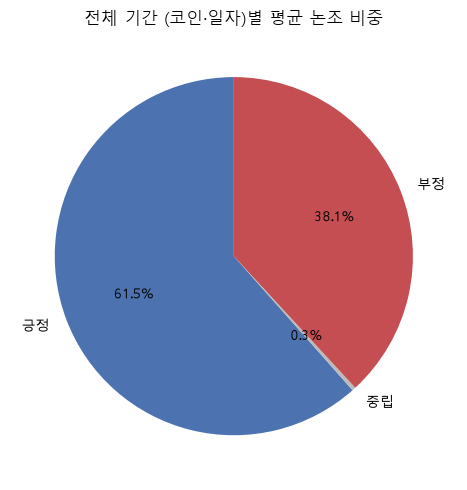

In [4]:
news_df["tone_class"] = np.select(
    [news_df["news_tone"] > 0, news_df["news_tone"] < 0],
    ["긍정", "부정"],
    default="중립",
)
tone_counts = news_df["tone_class"].value_counts().reindex(["긍정", "중립", "부정"]).fillna(0).astype(int)
print(tone_counts)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(tone_counts, labels=tone_counts.index, autopct="%1.1f%%",
       colors=["#4C72B0", "#BBBBBB", "#C44E52"], startangle=90)
ax.set_title("전체 기간 (코인·일자)별 평균 논조 비중")
plt.tight_layout()
plt.savefig("fig_news_tone_pie.png", dpi=110)
plt.show()


**실제 결과**: 전체 13,085건의 (코인·일자) 기록 중 긍정 논조가 8,052건(61.5%), 부정 논조가 4,990건(38.1%), 완전 중립(0.000)은 43건(0.3%)에 불과했다. 즉 GDELT가 집계한 코인 관련 보도는 이 5개 코인·전체 기간 기준으로 전반적으로 긍정 논조 쪽에 더 치우쳐 있었다.

### 3-2. 시세 데이터 수집

공개 API를 호출하는 방식이라 `robots.txt` 대상은 아니지만(HTML 페이지가 아닌 공식 API), 요청 사이에 `time.sleep()`으로 간격을 두어 서버에 부담을 주지 않도록 한다.


In [5]:
SYMBOLS = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT"]
INTERVAL = "4h"
LIMIT = 1000
END_TIME = 1784793739000    # 수집 기준 시각(고정 anchor) - 재실행해도 항상 같은 구간을 받아 재현성을 보장
START_TIME = 1483228800000  # 2017-01-01. 각 코인 상장 이전 시점 -> API가 실제 상장일부터 알아서 반환
SOURCE_URL = "https://api.binance.com/api/v3/klines"

def fetch_symbol(symbol):
    all_klines = []
    cursor = START_TIME
    while cursor < END_TIME:
        url = f"{SOURCE_URL}?symbol={symbol}&interval={INTERVAL}&startTime={cursor}&endTime={END_TIME}&limit={LIMIT}"
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=20) as resp:
            data = json.loads(resp.read().decode())
        if not data:
            break
        all_klines.extend(data)
        last_open_time = data[-1][0]
        if last_open_time <= cursor:
            break
        cursor = last_open_time + 1
        if len(data) < LIMIT:
            break
        time.sleep(0.25)
    return all_klines


In [6]:
raw_frames = []
for symbol in SYMBOLS:
    klines = fetch_symbol(symbol)
    d = pd.DataFrame(klines, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_vol", "trades", "taker_base", "taker_quote", "ignore",
    ])
    d = d[["open_time", "open", "high", "low", "close", "volume"]].astype({
        "open_time": "int64", "open": "float64", "high": "float64",
        "low": "float64", "close": "float64", "volume": "float64",
    })
    d["datetime"] = pd.to_datetime(d["open_time"], unit="ms")
    d["symbol"] = symbol
    raw_frames.append(d)
    print(f"{symbol}: {len(d)}개 캔들 수집 (기간 {d['datetime'].min()} ~ {d['datetime'].max()})")
    time.sleep(0.5)

raw_df = pd.concat(raw_frames, ignore_index=True)
raw_df.to_csv("raw_coin_4h.csv", index=False, encoding="utf-8-sig")
print(f"\n원본 데이터 저장 완료: raw_coin_4h.csv ({len(raw_df)}행)")


BTCUSDT: 19558개 캔들 수집 (기간 2017-08-17 04:00:00 ~ 2026-07-23 08:00:00)
ETHUSDT: 19558개 캔들 수집 (기간 2017-08-17 04:00:00 ~ 2026-07-23 08:00:00)
BNBUSDT: 19073개 캔들 수집 (기간 2017-11-06 00:00:00 ~ 2026-07-23 08:00:00)
SOLUSDT: 13034개 캔들 수집 (기간 2020-08-11 04:00:00 ~ 2026-07-23 08:00:00)
XRPUSDT: 18004개 캔들 수집 (기간 2018-05-04 08:00:00 ~ 2026-07-23 08:00:00)

원본 데이터 저장 완료: raw_coin_4h.csv (89227행)


## 4. 데이터 정제 및 특징·방향 라벨 생성

**결측치**: 두 종류의 결측치가 발생
- 앞부분: 이동평균/모멘텀/RSI 계산에 필요한 과거 데이터가 부족한 초반 구간은 계산이 불가능하므로 제거
- 뒷부분: '향후 저가/고가'를 라벨로 써야 하는데, 각 코인 데이터의 분석 시점 기준 미래 수익 계산이 불가능하므로 제거

**이상치**: 거래량 비율(`vol_ratio`)의 경우, 상장 초기 유동성이 매우 낮은 시기에 비정상적으로 튀는 경우가 있어 상위 0.1%를 그 값으로 캡핑(clip)했다. 삭제 대신 캡핑을 한 이유는 실제로 있었던 거래량 급증 상황 자체는 의미 있는 정보이므로 극단값의 영향만 줄이는 쪽을 택했다.

**방향 라벨(3분류)**: 각 시점의 **미래 실현수익률**(다음 N봉 뒤 종가 기준 순수익률)을 계산하고, 그 분포의 하위 10%를 `하락`, 상위 10%를 `상승`, 중간 80%를 `횡보`로 정의해 **하나의 3분류 변수**로 상승·횡보·하락을 한 번에 비교한다.
- 여기서 '횡보'는 가격이 실제로 거의 움직이지 않았다는 뜻이 아니며, 실제 데이터의 임계값을 직접 계산했을 때:
  - 단기(24h): 하락 ≤ -4.48%, 상승 ≥ +4.96% 
  - 장기(7일): 하락 ≤ -11.64%, 상승 ≥ +15.03%
으로 나타나 임계값 범위를 토대로 조정하였다. 또한 각 종목마다 변동성 스케일이 달라 개별 고정값으로 필터링 시 변동성이 큰 종목일수록 극단값이 높게 잡히므로, 분위수 기준 상하위 10%로 보정하였다.


In [7]:
SHORT_WINDOW = 6    # 4h * 6  = 24시간 뒤
LONG_WINDOW = 42    # 4h * 42 = 7일 뒤
MOMENTUM_LOOKBACK = 6
VOL_MA_WINDOW = 20
ATR_WINDOW = 14
RSI_WINDOW = 14
MA_WINDOW = 20
TAIL_QUANTILE = 0.10  # 하위/상위 10% = 하락/상승, 중간 80% = 횡보

def forward_return(close, window):
    future_close = close.shift(-window)
    return (future_close - close) / close * 100

def add_features_and_labels(df):
    df = df.sort_values("open_time").reset_index(drop=True)

    df["vol_ratio"] = df["volume"] / df["volume"].rolling(VOL_MA_WINDOW).mean()
    df["momentum_pct"] = df["close"].pct_change(MOMENTUM_LOOKBACK) * 100

    prev_close = df["close"].shift(1)
    tr = pd.concat([
        df["high"] - df["low"],
        (df["high"] - prev_close).abs(),
        (df["low"] - prev_close).abs(),
    ], axis=1).max(axis=1)
    atr = tr.rolling(ATR_WINDOW).mean()
    df["volatility_pct"] = atr / df["close"] * 100

    delta = df["close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/RSI_WINDOW, adjust=False, min_periods=RSI_WINDOW).mean()
    avg_loss = loss.ewm(alpha=1/RSI_WINDOW, adjust=False, min_periods=RSI_WINDOW).mean()
    rs = avg_gain / avg_loss
    df["rsi_14"] = 100 - 100 / (1 + rs)

    ma20 = df["close"].rolling(MA_WINDOW).mean()
    df["dist_from_ma20"] = (df["close"] - ma20) / ma20 * 100

    rng = (df["high"] - df["low"]).replace(0, np.nan)
    upper_wick = (df["high"] - df[["open", "close"]].max(axis=1)) / rng
    df["upper_wick_ratio"] = upper_wick.rolling(6).mean()

    up = (df["close"] > df["close"].shift(1)).astype(int)
    grp = (up != up.shift(1)).cumsum()
    df["consecutive_up"] = up.groupby(grp).cumsum() * up

    df["short_fwd_ret_pct"] = forward_return(df["close"], SHORT_WINDOW)
    df["long_fwd_ret_pct"] = forward_return(df["close"], LONG_WINDOW)
    return df

frames = [add_features_and_labels(g.copy()) for _, g in raw_df.groupby("symbol")]
full = pd.concat(frames, ignore_index=True)
print(f"정제 전 행 수: {len(full)}")


정제 전 행 수: 89227


In [8]:
FEATURE_COLS = ["vol_ratio", "momentum_pct", "volatility_pct", "rsi_14", "dist_from_ma20", "upper_wick_ratio", "consecutive_up"]
RET_COLS = ["short_fwd_ret_pct", "long_fwd_ret_pct"]

clean = full.dropna(subset=FEATURE_COLS + RET_COLS).reset_index(drop=True)
print(f"정제 후 행 수: {len(clean)}  (제거된 행: {len(full) - len(clean)})")

cap = clean["vol_ratio"].quantile(0.999)
n_capped = (clean["vol_ratio"] > cap).sum()
clean["vol_ratio"] = clean["vol_ratio"].clip(upper=cap)
print(f"극단적 거래량비율 이상치 {n_capped}건을 상위 0.1% 값({cap:.2f})으로 캡핑")

def make_direction(series, tail_q):
    low, high = series.quantile([tail_q, 1 - tail_q])
    return pd.cut(series, bins=[-np.inf, low, high, np.inf], labels=["하락", "횡보", "상승"]), low, high

clean["short_direction"], s_low, s_high = make_direction(clean["short_fwd_ret_pct"], TAIL_QUANTILE)
clean["long_direction"], l_low, l_high = make_direction(clean["long_fwd_ret_pct"], TAIL_QUANTILE)
clean["short_fwd_absret_pct"] = clean["short_fwd_ret_pct"].abs()
clean["long_fwd_absret_pct"] = clean["long_fwd_ret_pct"].abs()

print(f"\n단기(24h) 분류 기준: 하락 <= {s_low:.2f}% , 상승 >= {s_high:.2f}%")
print(f"장기(7일) 분류 기준: 하락 <= {l_low:.2f}% , 상승 >= {l_high:.2f}%")
print("\n단기 방향 분포:\n", clean["short_direction"].value_counts())
print("\n장기 방향 분포:\n", clean["long_direction"].value_counts())

clean.to_csv("coin_features_labeled.csv", index=False, encoding="utf-8-sig")
print(f"\n정제된 데이터 저장 완료: coin_features_labeled.csv ({len(clean)}행)")


정제 후 행 수: 88910  (제거된 행: 317)
극단적 거래량비율 이상치 89건을 상위 0.1% 값(5.50)으로 캡핑

단기(24h) 분류 기준: 하락 <= -4.48% , 상승 >= 4.96%
장기(7일) 분류 기준: 하락 <= -11.64% , 상승 >= 15.03%

단기 방향 분포:
 short_direction
횡보    71128
하락     8891
상승     8891
Name: count, dtype: int64

장기 방향 분포:
 long_direction
횡보    71128
하락     8891
상승     8891
Name: count, dtype: int64

정제된 데이터 저장 완료: coin_features_labeled.csv (88910행)


In [9]:
# 차트에 표시할 한글 라벨 (RSI 등 고유명사·약어는 그대로 유지)

SYMBOL_LABELS_KO = {
    "BTCUSDT": "비트코인",
    "ETHUSDT": "이더리움",
    "BNBUSDT": "바이낸스코인",
    "SOLUSDT": "솔라나",
    "XRPUSDT": "리플",
}

FEATURE_LABELS_KO = {
    "vol_ratio": "거래량비율",
    "momentum_pct": "모멘텀",
    "volatility_pct": "변동성(ATR)",
    "rsi_14": "RSI",
    "dist_from_ma20": "이동평균선 이격도",
    "upper_wick_ratio": "윗꼬리비율",
    "consecutive_up": "연속상승",
}

TARGET_LABELS_KO = {
    "short_fwd_ret_pct": "단기 방향성",
    "long_fwd_ret_pct": "장기 방향성",
    "short_fwd_absret_pct": "단기 변동 폭",
    "long_fwd_absret_pct": "장기 변동 폭",
}

NEWS_LABELS_KO = {
    "news_volume": "보도량",
    "news_tone": "논조",
}

def sig_stars(p):
    """유의확률(p-value)을 별표로 표시한다 (p<0.001=***, p<0.01=**, p<0.05=*)."""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

def annot_with_stars(r_df, p_df):
    """상관계수 값 뒤에 유의성 별표를 붙인 히트맵 주석용 문자열 DataFrame을 만든다."""
    return r_df.round(3).astype(str) + p_df.map(sig_stars)

print("차트 표시용 한글 라벨 및 유의성 표시 함수 정의 완료")

차트 표시용 한글 라벨 및 유의성 표시 함수 정의 완료


## 5. 분석 — 상승·하락 방향 비교

### 5-1. 방향별 특징 분포


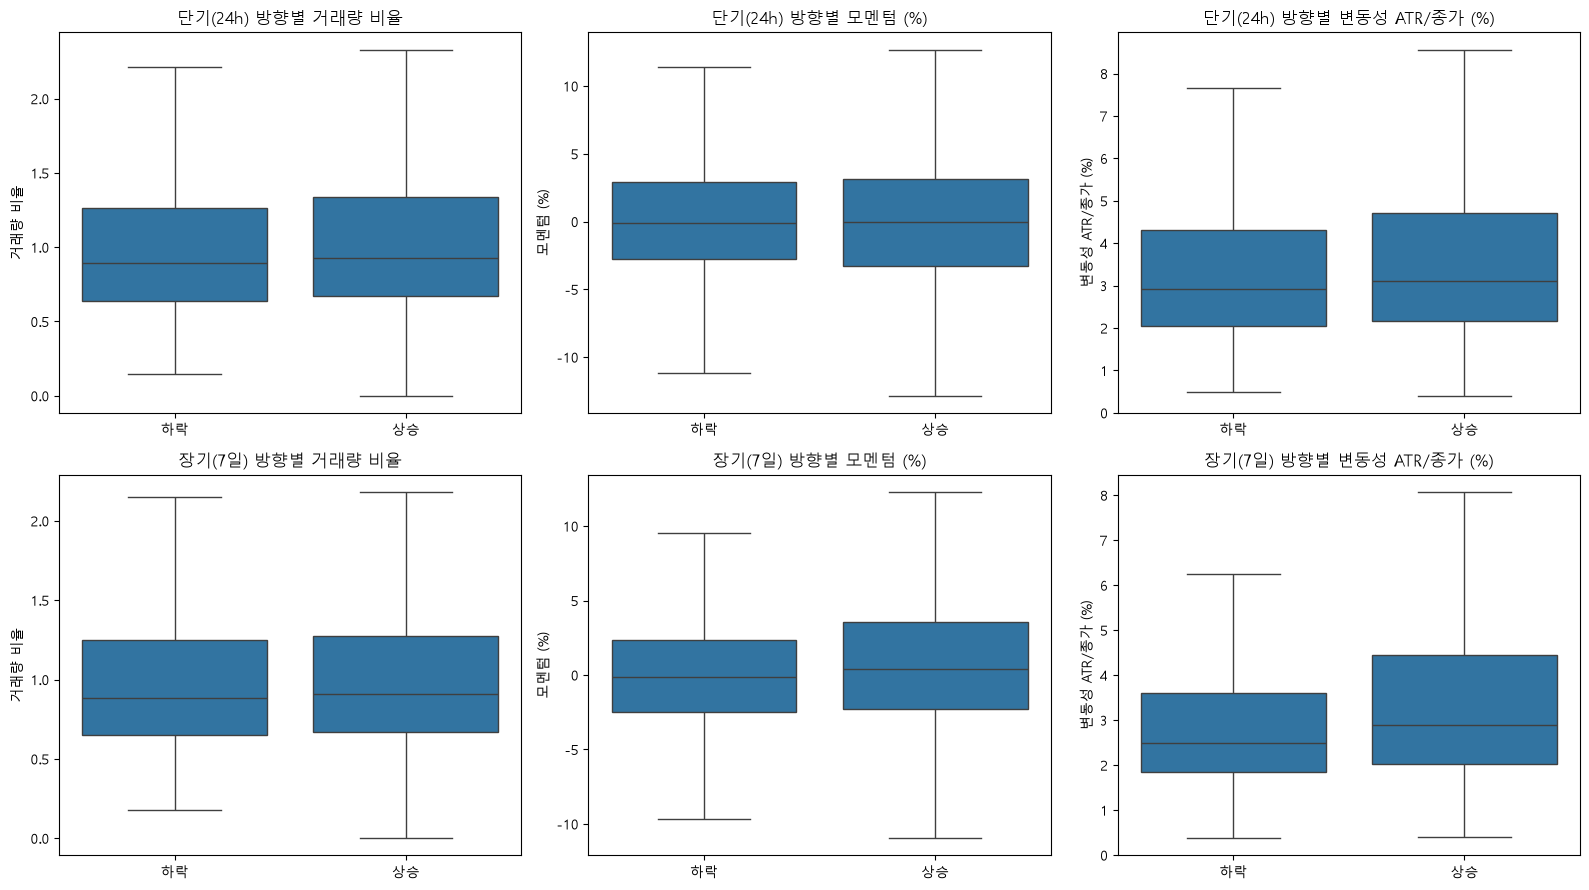

=== 하락 vs 상승 그룹 차이 유의성 (Mann-Whitney U 검정) ===
[단기(24h)] 거래량 비율: 하락 중앙값=0.896, 상승 중앙값=0.930, p=8.94e-09 ***
[단기(24h)] 모멘텀 (%): 하락 중앙값=-0.139, 상승 중앙값=-0.011, p=1.32e-01 
[단기(24h)] 변동성 ATR/종가 (%): 하락 중앙값=2.913, 상승 중앙값=3.108, p=6.04e-13 ***
[장기(7일)] 거래량 비율: 하락 중앙값=0.885, 상승 중앙값=0.909, p=1.34e-02 *
[장기(7일)] 모멘텀 (%): 하락 중앙값=-0.130, 상승 중앙값=0.393, p=1.27e-19 ***
[장기(7일)] 변동성 ATR/종가 (%): 하락 중앙값=2.499, 상승 중앙값=2.893, p=2.24e-57 ***


In [10]:
box_features = [
    ("vol_ratio", "거래량 비율"),
    ("momentum_pct", "모멘텀 (%)"),
    ("volatility_pct", "변동성 ATR/종가 (%)"),
]
DIR_ORDER = ["하락", "상승"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for row_i, (dir_col, row_label) in enumerate([("short_direction", "단기(24h)"), ("long_direction", "장기(7일)")]):
    for col_i, (feat, label) in enumerate(box_features):
        ax = axes[row_i, col_i]
        sns.boxplot(data=clean, x=dir_col, y=feat, order=DIR_ORDER, showfliers=False, ax=ax)
        ax.set_title(f"{row_label} 방향별 {label}")
        ax.set_xlabel("")
        ax.set_ylabel(label)

plt.tight_layout()
plt.savefig("fig1_feature_distributions.png", dpi=110)
plt.show()

# 하락/상승 두 그룹 중앙값 차이가 통계적으로 유의한지 Mann-Whitney U 검정으로 확인
# (수익률·거래량 등은 정규분포를 따르지 않는 경우가 많아 t검정 대신 비모수 검정을 사용)
print("=== 하락 vs 상승 그룹 차이 유의성 (Mann-Whitney U 검정) ===")
for dir_col, row_label in [("short_direction", "단기(24h)"), ("long_direction", "장기(7일)")]:
    for feat, label in box_features:
        down = clean.loc[clean[dir_col] == "하락", feat].dropna()
        up = clean.loc[clean[dir_col] == "상승", feat].dropna()
        u_stat, p = stats.mannwhitneyu(down, up, alternative="two-sided")
        print(f"[{row_label}] {label}: 하락 중앙값={down.median():.3f}, 상승 중앙값={up.median():.3f}, p={p:.2e} {sig_stars(p)}")

**해석**: 거래량 비율은 각 구간별 차이가 크지 않고, 단기 모멘텀 역시 두 방향 집단의 중앙값 차이가 거의 없어 방향 구분력이 낮지만 변동 범위가 넓다는 특징을 보인다. 장기 모멘텀에서는 상승 집단의 중앙값과 상위 사분위수가 하락 집단보다 다소 높아 약한 상승 방향성이 나타나지만, 집단 간 분포가 크게 겹쳐 단독 분류력은 제한적이다.

변동성(ATR/종가) 증가율의 중앙값은 장기 상승 구간에서 하락 구간보다 중앙값과 상위 분포가 상대적으로 높게 나타났다. 따라서 ATR은 기본적으로 변동성 확대를 나타내면서, 장기 기준에서는 상승 방향과도 일부 관련될 가능성이 있다. 다만 박스가 겹치는 부분이 있어, 단독 방향 지표로 해석하기 전에 통계적 유의성과 실제 분류력을 확인해야 한다.

### 5-2. 종목별 비교: 방향별 발생 비율

횡보 비중이 80%를 차지하여 하락·상승과 동일선상의 막대 그래프에서 비교 시 두 방향의 차이를 파악하기 힘든 관계로, 본 차트에서는 **하락·상승 비율만**, 단기·장기 시계열로 비교한다.

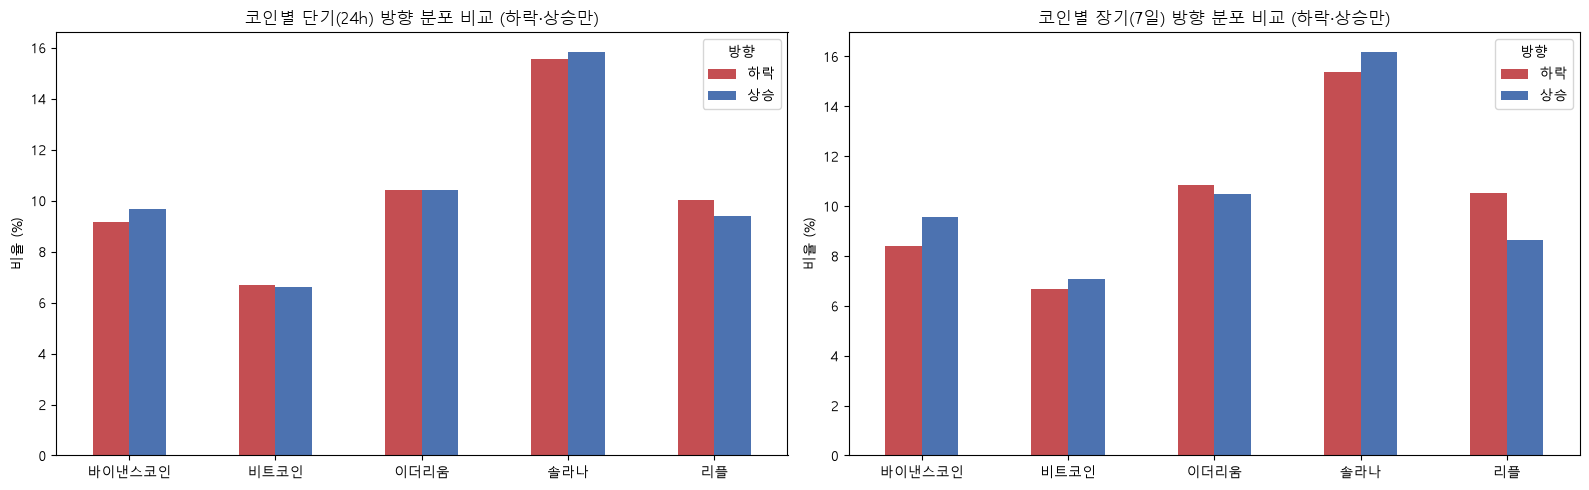

방향,하락,상승
symbol,,
바이낸스코인,9.152114,9.651799
비트코인,6.695398,6.613309
이더리움,10.415063,10.420194
솔라나,15.570801,15.809759
리플,10.009474,9.390849


In [21]:
prop_short = clean.groupby("symbol")["short_direction"].value_counts(normalize=True).unstack()[["하락", "상승"]] * 100
prop_short = prop_short.rename(index=SYMBOL_LABELS_KO).rename_axis(columns="방향")
prop_long = clean.groupby("symbol")["long_direction"].value_counts(normalize=True).unstack()[["하락", "상승"]] * 100
prop_long = prop_long.rename(index=SYMBOL_LABELS_KO).rename_axis(columns="방향")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
prop_short.plot(kind="bar", ax=axes[0], color=["#C44E52", "#4C72B0"])
axes[0].set_ylabel("비율 (%)")
axes[0].set_xlabel("")
axes[0].set_title("코인별 단기(24h) 방향 분포 비교 (하락·상승만)")
axes[0].legend(title="방향")
axes[0].tick_params(axis="x", rotation=0)

prop_long.plot(kind="bar", ax=axes[1], color=["#C44E52", "#4C72B0"])
axes[1].set_ylabel("비율 (%)")
axes[1].set_xlabel("")
axes[1].set_title("코인별 장기(7일) 방향 분포 비교 (하락·상승만)")
axes[1].legend(title="방향")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("fig3_symbol_comparison.png", dpi=110)
plt.show()

prop_short

**해석**: 코인마다 하락·상승 비율이 정확히 10%씩은 아니다 — 전체 5개 코인을 합쳐 산출한 임계값이므로, 개별 코인이 다른 코인보다 상대적으로 더 자주 극단값에 도달하면 비율이 10%를 넘거나 밑돈다. 예를 들어 변동성이 큰 코인은 하락·상승 비율이 모두 10%보다 높게 나타난다.

### 5-3. 상관관계 — 방향성 vs 변동 폭

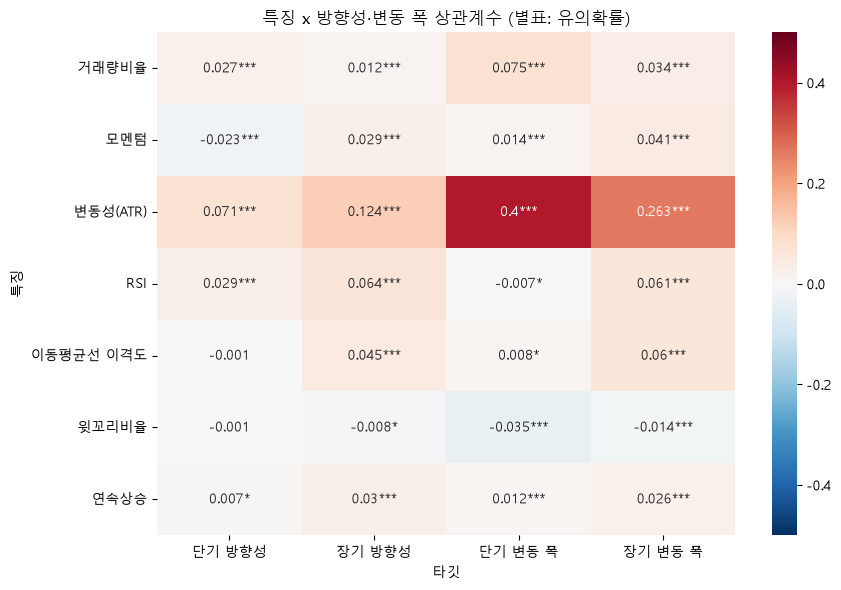

,단기 방향성,장기 방향성,단기 변동 폭,장기 변동 폭
거래량비율,0.026916,0.012169,0.075491,0.033535
모멘텀,-0.022966,0.028697,0.013656,0.041474
변동성(ATR),0.071191,0.123791,0.399689,0.262979
RSI,0.028944,0.064178,-0.006863,0.060534
이동평균선 이격도,-0.000938,0.045100,0.008102,0.059700
윗꼬리비율,-0.001278,-0.008085,-0.035256,-0.013964
연속상승,0.007228,0.029524,0.011522,0.025594


In [11]:
TARGET_COLS = ["short_fwd_ret_pct", "long_fwd_ret_pct", "short_fwd_absret_pct", "long_fwd_absret_pct"]
corr = clean[FEATURE_COLS + TARGET_COLS].corr()
heat = corr.loc[FEATURE_COLS, TARGET_COLS].rename(index=FEATURE_LABELS_KO, columns=TARGET_LABELS_KO)

# 상관계수 옆에 유의확률(p-value)을 별표로 함께 표시 (*p<0.05, **p<0.01, ***p<0.001)
pvals = pd.DataFrame(index=FEATURE_COLS, columns=TARGET_COLS, dtype=float)
for feat in FEATURE_COLS:
    for tgt in TARGET_COLS:
        _, p = stats.pearsonr(clean[feat], clean[tgt])
        pvals.loc[feat, tgt] = p
pvals = pvals.rename(index=FEATURE_LABELS_KO, columns=TARGET_LABELS_KO)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heat, annot=annot_with_stars(heat, pvals), fmt="", cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5, ax=ax)
ax.set_title("특징 x 방향성·변동 폭 상관계수 (별표: 유의확률)")
ax.set_xlabel("타깃")
ax.set_ylabel("특징")
plt.tight_layout()
plt.savefig("fig2_correlation_heatmap.png", dpi=110)
plt.show()

heat

**해석 (핵심 결과)**: `volatility_pct`는 **방향성과는 상관계수가 거의 0**인 반면, **변동 폭과는 어느정도의 상관관계**(단기 +0.4 안팎)를 보인다. 이는 "향후 시점의 변동 폭" 자체는 암시가 가능하나, 그 방향은 예측하기 어렵다는 의미이다. 나머지 특징들은 방향성·변동 폭 어느 쪽과도 상관계수 절대값이 0.1 미만으로 뚜렷한 신호가 없다.

흥미로운 점은 각 28개 조합 중 26개가 통계적으로 유의한 것으로 나타났는데, 이는 표본 크기가 매우 많아 아주 작은 상관관계도 유의하다고 판정되기 때문이다.¹

¹t = r × √((n-2) / (1-r²))

따라서 통계적으로 유의한지 여부보다 상관계수 크기 자체를 봐야 한다.

### 5-4. 방향(하락·상승)별 특징-변동폭 상관계수

5-3의 상관계수는 전체 데이터를 한 번에 본 값이다. 같은 계산을 **하락·상승 두 그룹으로 나누어 따로** 보면 신호가 특정 방향의 움직임에서만 강하게 나타나는지, 두 방향 모두에서 비슷한지를 구분할 수 있다. (그룹을 이미 변동 폭 분위수로 나눠 놓았으므로 그룹 내부의 변동 폭 범위가 좁아져 상관계수 절대값 자체는 전체 대비 작게 나오기 쉽다 — 그룹 간 **상대적 크기 비교**에 의미를 둔다.)

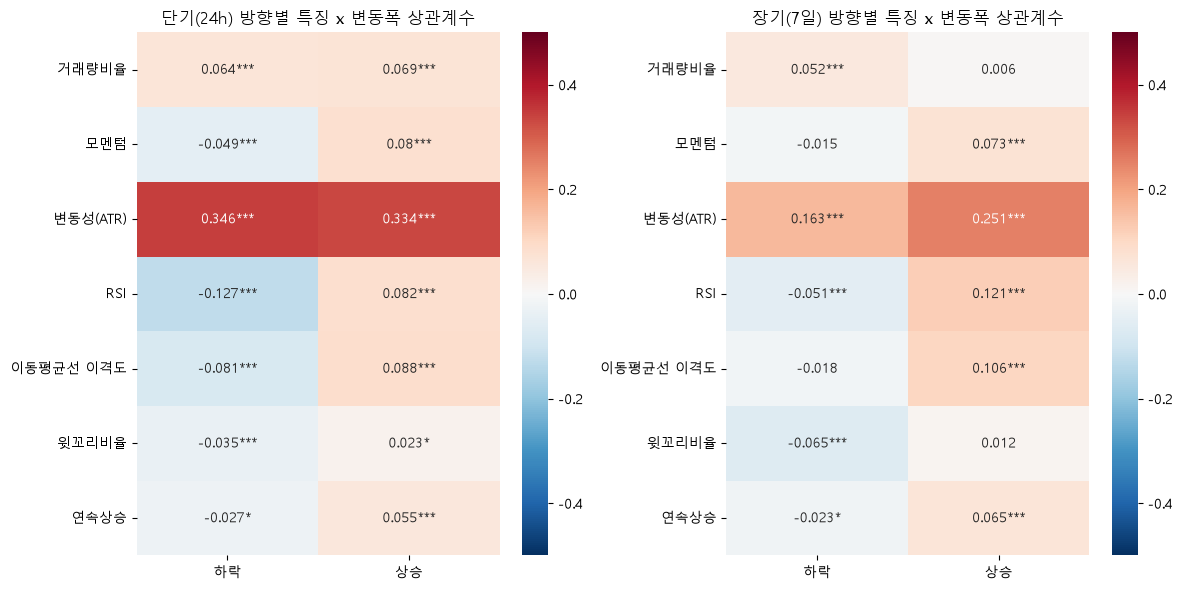

,하락,상승
거래량비율,0.064272,0.068638
모멘텀,-0.049306,0.079564
변동성(ATR),0.346008,0.333735
RSI,-0.127474,0.082363
이동평균선 이격도,-0.080749,0.088126
윗꼬리비율,-0.035157,0.023246
연속상승,-0.027019,0.054775


In [13]:
def direction_corr_table(df, direction_col, feature_cols, target_col, label_map=None):
    """방향(하락/상승) 그룹별로 feature_cols 각각과 target_col의 상관계수(r)와 유의확률(p)을 구해 표로 반환한다."""
    r_table, p_table = {}, {}
    for d in DIR_ORDER:
        sub = df.loc[df[direction_col] == d]
        r_table[d] = {}
        p_table[d] = {}
        for feat in feature_cols:
            r, p = stats.pearsonr(sub[feat], sub[target_col])
            r_table[d][feat] = r
            p_table[d][feat] = p
    r_df = pd.DataFrame(r_table)[DIR_ORDER]
    p_df = pd.DataFrame(p_table)[DIR_ORDER]
    if label_map:
        r_df = r_df.rename(index=label_map)
        p_df = p_df.rename(index=label_map)
    return r_df, p_df

short_dir_corr, short_dir_p = direction_corr_table(clean, "short_direction", FEATURE_COLS, "short_fwd_absret_pct", FEATURE_LABELS_KO)
long_dir_corr, long_dir_p = direction_corr_table(clean, "long_direction", FEATURE_COLS, "long_fwd_absret_pct", FEATURE_LABELS_KO)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(short_dir_corr, annot=annot_with_stars(short_dir_corr, short_dir_p), fmt="", cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5, ax=axes[0])
axes[0].set_title("단기(24h) 방향별 특징 x 변동폭 상관계수")
sns.heatmap(long_dir_corr, annot=annot_with_stars(long_dir_corr, long_dir_p), fmt="", cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5, ax=axes[1])
axes[1].set_title("장기(7일) 방향별 특징 x 변동폭 상관계수")
plt.tight_layout()
plt.savefig("fig5_direction_corr_market.png", dpi=110)
plt.show()

short_dir_corr

**해석**: 변동성이 두 그룹 모두에서 비슷한 크기의 양의 상관을 보이면 5-3에서 확인한 방향과 무관하게 변동폭을 예고하는 패턴이 그룹을 나누어도 유지된다는 뜻이다. 반대로 상승 또는 하락과 같이 특정 방향에서만 상관계수가 뚜렷하게 크다면 그 특징은 해당 방향의 움직임에서 더 강하게 작동하는 신호로 볼 수 있다.

실제 결과는 변동성이 하락·상승 두 그룹의 단기·장기 모두에서 r=0.16~0.35 수준의 양의 상관을 유지했으며, 5-2에서 본 패턴이 그룹을 나누어도 그대로 유지된다. 나머지 특징은 대체로 r이 0.1 미만이지만, RSI는 하락 그룹에서 음의 상관(단기 -0.127, 장기 -0.051), 상승 그룹에서는 양의 상관(단기 +0.082, 장기 +0.121)으로 **부호 자체가 방향에 따라 바뀌는 유일한 특징**이었다 — 하락 국면에서는 RSI가 낮을수록, 상승 국면에서는 RSI가 높을수록 변동폭이 커지는 경향이 약하게나마 있다는 뜻이다.

### 5-5. 시간대(UTC)별·평일/주말별 방향 분포

같은 이유(횡보 비중이 과반 이상을 차지)로 본 비교도 **하락·상승 비율만** 확인한다. 4시간봉 기준으로 시간대는 0/4/8/12/16/20시(UTC) 6구간이다.

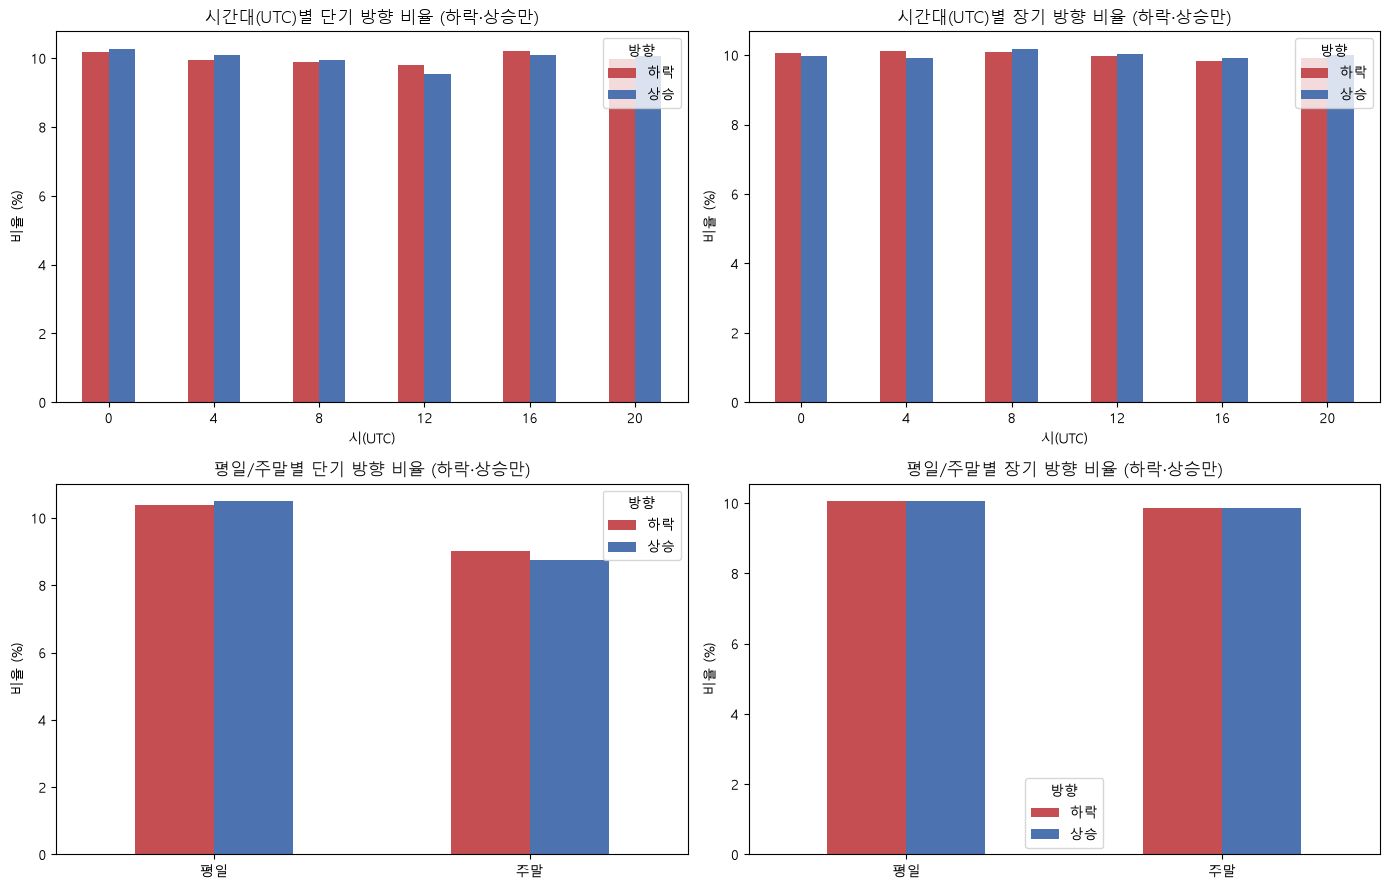

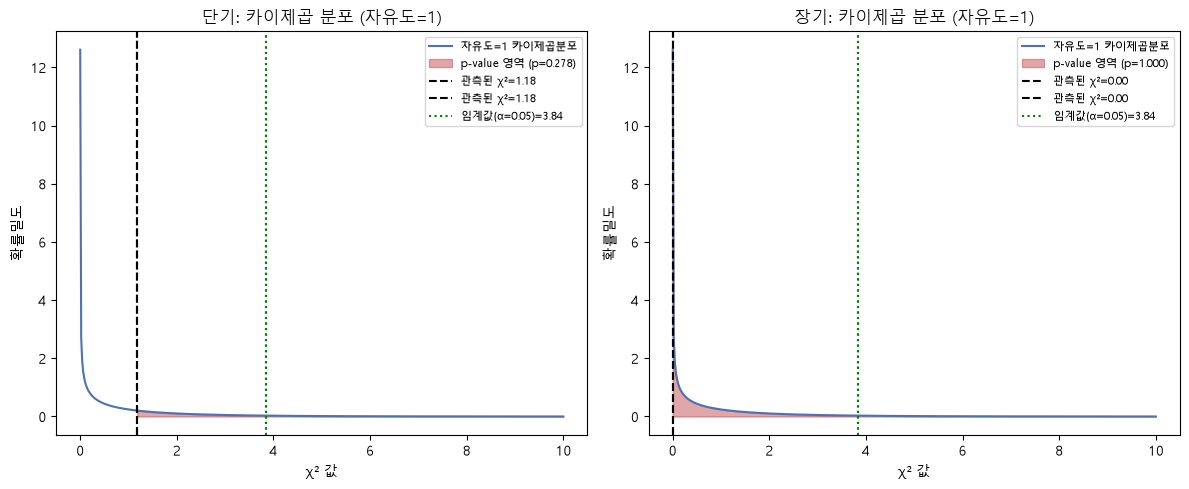

In [24]:
clean["hour"] = clean["datetime"].dt.hour
clean["is_weekend"] = clean["datetime"].dt.dayofweek >= 5
clean["요일구분"] = clean["is_weekend"].map({True: "주말", False: "평일"})

hour_prop_short = clean.groupby("hour")["short_direction"].value_counts(normalize=True).unstack()[["하락", "상승"]].rename_axis(columns="방향") * 100
hour_prop_long = clean.groupby("hour")["long_direction"].value_counts(normalize=True).unstack()[["하락", "상승"]].rename_axis(columns="방향") * 100
weekend_prop_short = clean.groupby("요일구분")["short_direction"].value_counts(normalize=True).unstack()[["하락", "상승"]].rename_axis(columns="방향") * 100
weekend_prop_short = weekend_prop_short.reindex(["평일", "주말"])
weekend_prop_long = clean.groupby("요일구분")["long_direction"].value_counts(normalize=True).unstack()[["하락", "상승"]].rename_axis(columns="방향") * 100
weekend_prop_long = weekend_prop_long.reindex(["평일", "주말"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
hour_prop_short.plot(kind="bar", ax=axes[0, 0], color=["#C44E52", "#4C72B0"])
axes[0, 0].set_title("시간대(UTC)별 단기 방향 비율 (하락·상승만)")
axes[0, 0].set_xlabel("시(UTC)")
axes[0, 0].set_ylabel("비율 (%)")
axes[0, 0].legend(title="방향")
axes[0, 0].tick_params(axis="x", rotation=0)

hour_prop_long.plot(kind="bar", ax=axes[0, 1], color=["#C44E52", "#4C72B0"])
axes[0, 1].set_title("시간대(UTC)별 장기 방향 비율 (하락·상승만)")
axes[0, 1].set_xlabel("시(UTC)")
axes[0, 1].set_ylabel("비율 (%)")
axes[0, 1].legend(title="방향")
axes[0, 1].tick_params(axis="x", rotation=0)

weekend_prop_short.plot(kind="bar", ax=axes[1, 0], color=["#C44E52", "#4C72B0"])
axes[1, 0].set_title("평일/주말별 단기 방향 비율 (하락·상승만)")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("비율 (%)")
axes[1, 0].legend(title="방향")
axes[1, 0].tick_params(axis="x", rotation=0)

weekend_prop_long.plot(kind="bar", ax=axes[1, 1], color=["#C44E52", "#4C72B0"])
axes[1, 1].set_title("평일/주말별 장기 방향 비율 (하락·상승만)")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("비율 (%)")
axes[1, 1].legend(title="방향")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("fig7_time_weekday_direction.png", dpi=110)
plt.show()

# 평일/주말에 따라 방향(하락·상승) 비율이 실제로 다른지 카이제곱 독립성 검정으로 확인
from scipy.stats import chi2 as chi2_dist

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (dir_col, label) in zip(axes, [("short_direction", "단기"), ("long_direction", "장기")]):
    ct = pd.crosstab(clean["요일구분"], clean[dir_col].where(clean[dir_col].isin(["하락", "상승"])))
    chi2_stat, p, dof, expected = stats.chi2_contingency(ct)

    x = np.linspace(0.001, max(10, chi2_stat * 1.5, chi2_dist.ppf(0.99, dof) * 1.2), 500)
    y = chi2_dist.pdf(x, dof)
    ax.plot(x, y, color="#4C72B0", label=f"자유도={dof} 카이제곱분포")

    # 관측된 통계량보다 오른쪽 = p-value에 해당하는 영역
    x_fill = x[x >= chi2_stat]
    ax.fill_between(x_fill, chi2_dist.pdf(x_fill, dof), color="#C44E52", alpha=0.5,
                     label=f"p-value 영역 (p={p:.3f})")

    ax.axvline(chi2_stat, color="black", linestyle="--", label=f"관측된 χ²={chi2_stat:.2f}")

    crit = chi2_dist.ppf(0.95, dof)  # 유의수준 0.05 기준 임계값
    ax.axvline(crit, color="green", linestyle=":"), 

    ax.axvline(chi2_stat, color="black", linestyle="--", label=f"관측된 χ²={chi2_stat:.2f}")

    crit = chi2_dist.ppf(0.95, dof)  # 유의수준 0.05 기준 임계값
    ax.axvline(crit, color="green", linestyle=":", label=f"임계값(α=0.05)={crit:.2f}")

    ax.set_title(f"{label}: 카이제곱 분포 (자유도={dof})")
    ax.set_xlabel("χ² 값")
    ax.set_ylabel("확률밀도")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**해석**: 특정 시간대(UTC)에서 하락·상승 비율이 다른 시간대보다 뚜렷하게 치우쳐 있다면, 그 시간대에 겹치는 거래 세션(아시아/유럽/미국 개장 시간)과 관련이 있을 수 있다. 평일과 주말 사이에 차이가 크다면, 주말의 상대적으로 낮은 유동성이 방향성에 영향을 준다는 해석이 가능하다.

시간대별 비율은 단기·장기 모두 9.5~10.3% 사이에서 거의 평평했다. 평일/주말도 마찬가지로, 단기는 평일(10.40/10.50) vs 주말(9.01/8.76)로 약간 차이가 있어 보이지만, 카이제곱 검정 결과 유의수준 0.05 기준 임계값(χ²)은 약 3.84로 실제 관측값(1.18)보다 좌측에 위치해 있어 유의하지 않았고, 장기는 평일(10.06/10.06) vs 주말(9.86/9.86)로 사실상 동일하였다. 한마디로 **본 데이터에서는 시간대나 요일에 따른 방향성 편향의 증거를 찾지 못했다.**

## 6. 뉴스-가격 관계 분석

시세는 4시간 단위, 뉴스는 일 단위(UTC 00:00~24:00 집계)라 그레인이 다르다. 또한 코인은 24시간 거래되므로, D일 하루 동안 나온 뉴스를 D일 00:00 시점의 가격과 그대로 비교하면 그날 늦게 보도된 뉴스가 이미 지나간 가격 움직임을 미리 맞힌 것처럼 보이는 시점 역전(look-ahead) 문제가 생길 수 있다. 이를 피하기 위해 **D일의 뉴스는 D+1일의 첫 4시간봉(01:00 UTC)을 대표값으로 삼아 비교**한다 — 이를 통해 D일 하루 뉴스 전체가 측정 시점보다 항상 앞서게 된다.


In [15]:
clean["date"] = clean["datetime"].dt.floor("D")
daily = clean.sort_values("open_time").groupby(["symbol", "date"]).first().reset_index()

news_shifted = news_df.copy()
news_shifted["date"] = news_shifted["date"] + pd.Timedelta(days=1)  # D일 뉴스 -> D+1일 가격과 결합
merged = daily.merge(news_shifted, on=["symbol", "date"], how="inner")
merged = merged.dropna(subset=["news_volume", "news_tone"])
print(f"뉴스와 결합된 일별 데이터: {len(merged)}행")
merged.to_csv("coin_news_merged.csv", index=False, encoding="utf-8-sig")


뉴스와 결합된 일별 데이터: 11242행


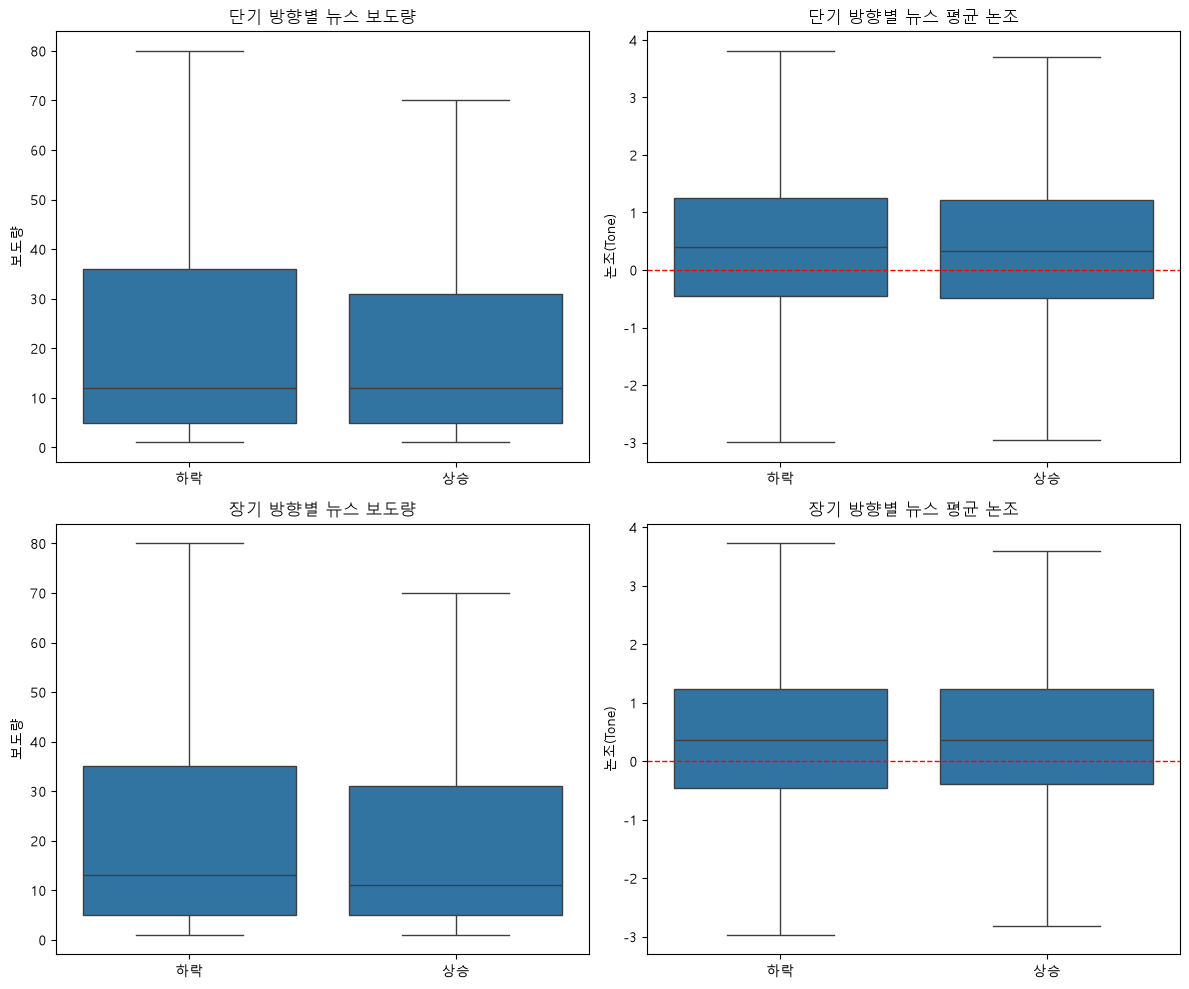

=== 하락 vs 상승 뉴스 지표 차이 유의성 (Mann-Whitney U 검정) ===
[단기] 보도량: 하락 중앙값=12.000, 상승 중앙값=12.000, p=4.37e-01 
[단기] 논조: 하락 중앙값=0.400, 상승 중앙값=0.327, p=5.51e-01 
[장기] 보도량: 하락 중앙값=13.000, 상승 중앙값=11.000, p=3.05e-02 *
[장기] 논조: 하락 중앙값=0.354, 상승 중앙값=0.366, p=6.80e-01 


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(data=merged, x="short_direction", y="news_volume", order=DIR_ORDER, showfliers=False, ax=axes[0, 0])
axes[0, 0].set_title("단기 방향별 뉴스 보도량")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("보도량")

sns.boxplot(data=merged, x="short_direction", y="news_tone", order=DIR_ORDER, showfliers=False, ax=axes[0, 1])
axes[0, 1].set_title("단기 방향별 뉴스 평균 논조")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("논조(Tone)")
axes[0, 1].axhline(0, color="red", linestyle="--", linewidth=1)

sns.boxplot(data=merged, x="long_direction", y="news_volume", order=DIR_ORDER, showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title("장기 방향별 뉴스 보도량")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("보도량")

sns.boxplot(data=merged, x="long_direction", y="news_tone", order=DIR_ORDER, showfliers=False, ax=axes[1, 1])
axes[1, 1].set_title("장기 방향별 뉴스 평균 논조")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("논조(Tone)")
axes[1, 1].axhline(0, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig("fig4_news_by_direction.png", dpi=110)
plt.show()

# 하락/상승 두 그룹 간 뉴스 지표 차이가 통계적으로 유의한지 Mann-Whitney U 검정으로 확인
print("=== 하락 vs 상승 뉴스 지표 차이 유의성 (Mann-Whitney U 검정) ===")
for dir_col, label in [("short_direction", "단기"), ("long_direction", "장기")]:
    for feat, feat_label in [("news_volume", "보도량"), ("news_tone", "논조")]:
        down = merged.loc[merged[dir_col] == "하락", feat].dropna()
        up = merged.loc[merged[dir_col] == "상승", feat].dropna()
        u_stat, p = stats.mannwhitneyu(down, up, alternative="two-sided")
        print(f"[{label}] {feat_label}: 하락 중앙값={down.median():.3f}, 상승 중앙값={up.median():.3f}, p={p:.2e} {sig_stars(p)}")

**해석**: 단기 기준으로는 보도량과 논조 모두 하락·상승 그룹 간 차이가 미미하였다. 장기 기준에서는 논조는 여전히 유의하지 않았지만, 보도량은 하락 중앙값이 13.0으로 상승(11.0)보다 높아 약하게 유의했다 — 즉 7일 뒤 하락한 코인은 그 전날 뉴스가 조금 더 많이 나왔을 가능성을 시사하지만, 단기에서는 같은 패턴이 보이지 않아 일관된 신호로 보기는 어렵다.

=== 뉴스 지표 x 미래수익률 상관계수 (전체) ===
             short_fwd_ret_pct  short_fwd_absret_pct  long_fwd_ret_pct  \
news_volume          -0.009267             -0.013908         -0.017863   
news_tone             0.006016             -0.026189          0.005575   

             long_fwd_absret_pct  
news_volume            -0.034413  
news_tone              -0.001993  

=== 유의확률(p-value) ===


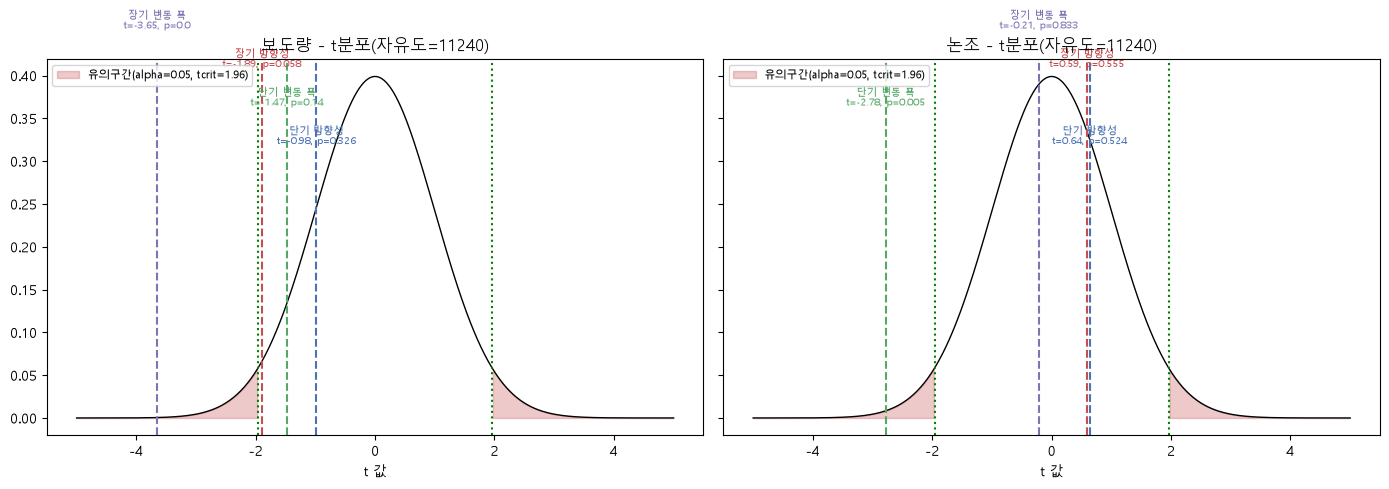

In [33]:
news_corr = merged[["news_volume", "news_tone", "short_fwd_ret_pct", "short_fwd_absret_pct",
                     "long_fwd_ret_pct", "long_fwd_absret_pct"]].corr()
print("=== 뉴스 지표 x 미래수익률 상관계수 (전체) ===")
print(news_corr.loc[["news_volume", "news_tone"],
                     ["short_fwd_ret_pct", "short_fwd_absret_pct", "long_fwd_ret_pct", "long_fwd_absret_pct"]])

print("\n=== 유의확률(p-value) ===")
from scipy.stats import t as t_dist

n = len(merged)
dof = n - 2
t_crit = t_dist.ppf(0.975, dof)

x = np.linspace(-5, 5, 500)
y = t_dist.pdf(x, dof)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

feat_targets = {
    "news_volume": [
        "short_fwd_ret_pct",
        "short_fwd_absret_pct",
        "long_fwd_ret_pct",
        "long_fwd_absret_pct",
    ],
    "news_tone": [
        "short_fwd_ret_pct",
        "short_fwd_absret_pct",
        "long_fwd_ret_pct",
        "long_fwd_absret_pct",
    ],
}
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

sig_label = "유의구간(alpha=0.05, tcrit=" + str(round(t_crit, 2)) + ")"

for ax, feat in zip(axes, feat_targets.keys()):
    targets = feat_targets[feat]
    ax.plot(x, y, color="black", linewidth=1)

    left_mask = x <= -t_crit
    right_mask = x >= t_crit

    ax.fill_between(x[left_mask], y[left_mask], color="#C44E52", alpha=0.3)
    ax.fill_between(x[right_mask], y[right_mask], color="#C44E52", alpha=0.3, label=sig_label)

    ax.axvline(-t_crit, color="green", linestyle=":")
    ax.axvline(t_crit, color="green", linestyle=":")

    for i, tgt in enumerate(targets):
        r, p = stats.pearsonr(merged[feat], merged[tgt])
        t_stat = r * np.sqrt((n - 2) / (1 - r ** 2))

        t_label = TARGET_LABELS_KO.get(tgt, tgt)
        t_str = str(round(t_stat, 2))
        p_str = str(round(p, 3))
        point_label = t_label + "\nt=" + t_str + ", p=" + p_str

        ax.axvline(t_stat, color=colors[i], linestyle="--")
        y_pos = 0.32 + i * 0.045
        ax.annotate(point_label, xy=(t_stat, 0), xytext=(t_stat, y_pos),
                    fontsize=7, color=colors[i], ha="center")

    feat_label = NEWS_LABELS_KO.get(feat, feat)
    ax.set_title(feat_label + " - t분포(자유도=" + str(dof) + ")")
    ax.set_xlabel("t 값")
    ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

**해석**: 뉴스 보도량이 향후 수익률의 **크기**(변동 폭)와 어느 정도 연관되는지, 논조가 향후 **방향**(상승/하락)과 연관되는지를 함께 본다. 보도량이 크기와 더 강하게 연관되고 방향과는 약하다면, 이는 "많이 보도된다는 것 자체가 이미 큰 변동이 진행 중이라는 신호"에 가깝고, 뉴스가 사전에 방향을 예고하기보다 사후적으로 따라간다는 해석에 무게가 실린다. 반대로 논조가 방향과 유의미하게 연관된다면, 보도의 긍정·부정 논조가 실제로 향후 가격 방향과 관련이 있다는 뜻이 된다.

실제 결과에 따르면 상관계수가 전부 |r|<0.04로 매우 작았으며, **뉴스 보도량·논조와 이후 가격 변동 사이에 의미 있는 선형 관계를 찾지 못했다** — 보도량-장기변동폭의 음의 상관은 오히려 예상과 반대 방향(보도가 많을수록 변동폭이 작다)인데, r이 -0.034로 극히 작아 실질적 의미를 부여하기 어렵다.

### 6-1. 방향(하락·상승)별 뉴스 지표 상관계수

5-4와 같은 방식으로, 뉴스 지표(보도량·논조)와 변동폭의 상관계수도 방향 두 그룹으로 나누어 따로 본다. 시장 특징(5-4)과 뉴스 지표(아래)를 같은 틀로 비교하면, 뉴스가 시장 특징보다 특정 방향에서 더 혹은 덜 뚜렷한 신호인지를 나란히 확인할 수 있다.

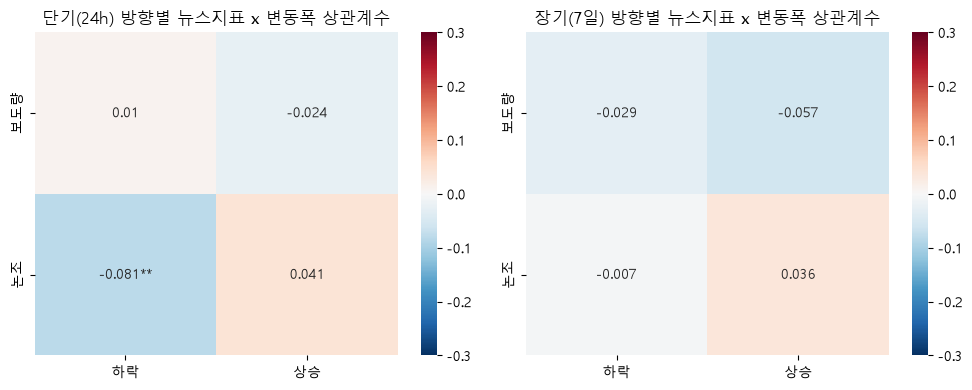

,하락,상승
보도량,0.010425,-0.024429
논조,-0.081258,0.041487


In [18]:
short_news_dir_corr, short_news_dir_p = direction_corr_table(merged, "short_direction", ["news_volume", "news_tone"], "short_fwd_absret_pct", NEWS_LABELS_KO)
long_news_dir_corr, long_news_dir_p = direction_corr_table(merged, "long_direction", ["news_volume", "news_tone"], "long_fwd_absret_pct", NEWS_LABELS_KO)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(short_news_dir_corr, annot=annot_with_stars(short_news_dir_corr, short_news_dir_p), fmt="", cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.3, ax=axes[0])
axes[0].set_title("단기(24h) 방향별 뉴스지표 x 변동폭 상관계수")
sns.heatmap(long_news_dir_corr, annot=annot_with_stars(long_news_dir_corr, long_news_dir_p), fmt="", cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.3, ax=axes[1])
axes[1].set_title("장기(7일) 방향별 뉴스지표 x 변동폭 상관계수")
plt.tight_layout()
plt.savefig("fig6_direction_corr_news.png", dpi=110)
plt.show()

short_news_dir_corr

**해석**: 뉴스 보도량·논조와 변동폭의 상관관계가 하락·상승 두 그룹 중 특정 그룹에서만 두드러진다면, 뉴스가 모든 국면에서 똑같이 작동하는 신호가 아니라 특정 방향의 움직임에 더 민감하게 반응(혹은 후행)한다는 뜻이다. 두 그룹에서 비슷한 크기라면 6절 전체 상관계수의 해석이 방향에 관계없이 일반적으로 성립한다고 볼 수 있다.

8개 조합 중 유의했던 건 단기 하락 그룹의 논조 하나뿐이다(r=-0.081, p=0.0054) — 하락 국면에서는 논조가 더 부정적일수록 변동폭이 소폭 커지는 경향이다. 나머지 7개 조합은 전부 유의하지 않았다. 전체적으로 6절에서 확인한 바와 같이 뉴스 지표가 특정 방향에서 더 강하게 작동한다는 뚜렷한 관계는 없음이 유지된다.

## 7. 특징 페어플롯 (하락 vs 상승)

### 7-1. 단기(7일) 기준 페어플롯

5-2 및 5-4의 상관계수는 특징과 방향성의 선형 관계만 보았다. 특징끼리 짝지어 산점도로 보면 단일 상관계수로는 보이지 않는 비선형·결합 패턴이 있는지 확인할 수 있다. 역시 횡보 구간 데이터를 제외하고, 점이 너무 많아 무거워지지 않도록 방향별로 표본을 추려 사용한다.


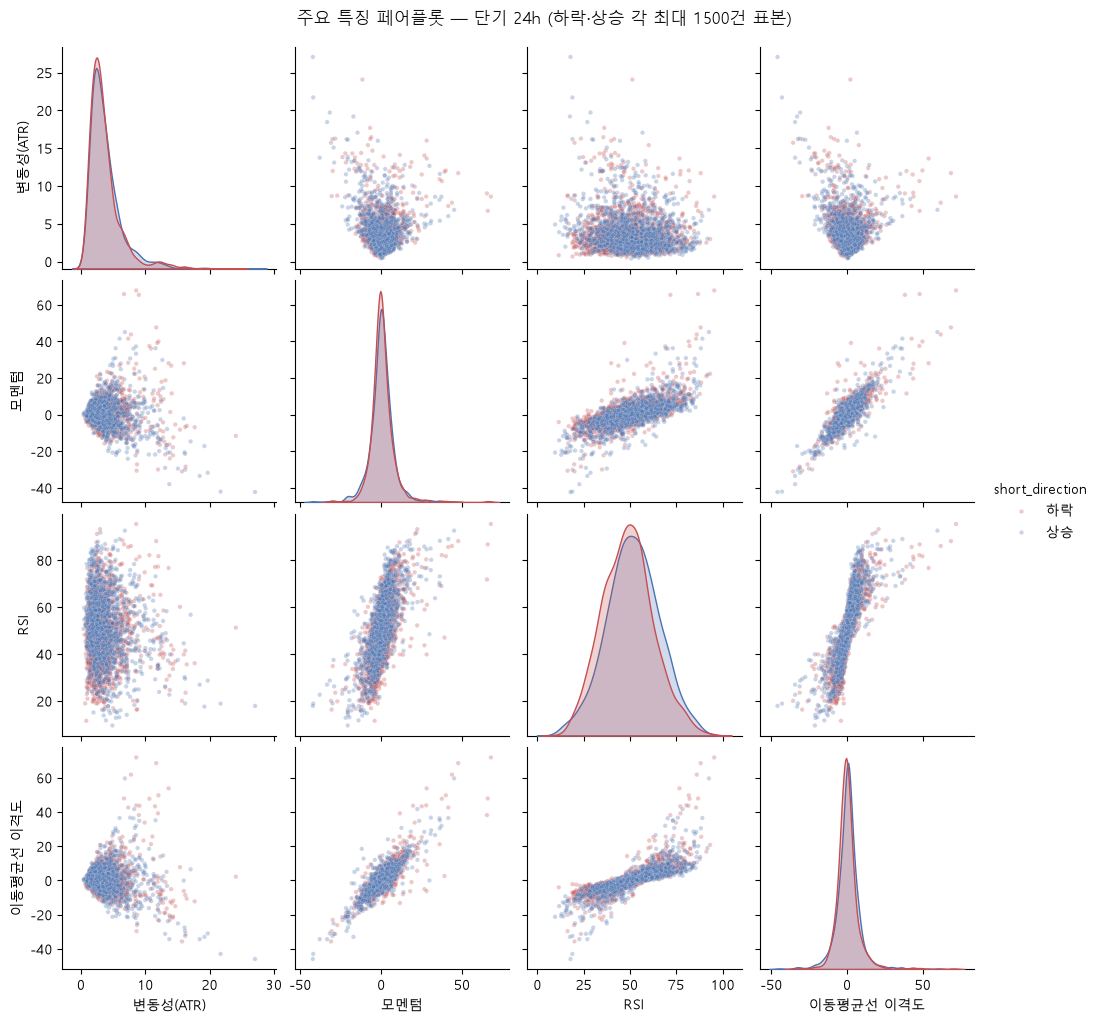

In [19]:
PAIR_FEATURES = ["volatility_pct", "momentum_pct", "rsi_14", "dist_from_ma20"]
SAMPLE_PER_DIR = 1500

pair_source = clean[clean["short_direction"].isin(["하락", "상승"])]
pair_sample = pd.concat([
    grp.sample(min(len(grp), SAMPLE_PER_DIR), random_state=42)
    for _, grp in pair_source.groupby("short_direction", observed=True)
])
pair_df = pair_sample[PAIR_FEATURES + ["short_direction"]].rename(columns=FEATURE_LABELS_KO)

g = sns.pairplot(pair_df, hue="short_direction", hue_order=["하락", "상승"],
                  palette={"하락": "#C44E52", "상승": "#4C72B0"},
                  plot_kws={"alpha": 0.3, "s": 10}, diag_kind="kde")
g.fig.suptitle(f"주요 특징 페어플롯 — 단기 24h (하락·상승 각 최대 {SAMPLE_PER_DIR}건 표본)", y=1.02)
g.savefig("fig8_pairplot.png", dpi=110)
plt.show()

**해석**: 대각선은 각 특징의 하락/상승 분포를, 비대각 산점도는 두 특징을 함께 봤을 때 하락(빨강)과 상승(파랑)이 갈라지는 조합이 있는지를 보여준다. 어느 조합에서도 두 색이 뚜렷하게 갈라지지 않는다면 5-2·5-4의 낮은 상관계수가 두 변수 조합으로도 잘 설명되지 않는다는 뜻이고, 반대로 특정 조합에서 군집이 갈라진다면 개별 상관계수만으로는 못 본 신호 후보가 된다.

결과는 4개 특징(변동성, 모멘텀, RSI, 이동평균선 이격도) 모두 단기 방향성과의 상관계수가 낮게 나타났다. 개별 상관이 이처럼 약하면 두 변수를 같이 봐도 강한 군집 분리가 나타나기는 어렵다 — 실제로 대각선 KDE 분포도 하락·상승이 대부분 겹치고, 비대각 산점도에서도 두 색이 뒤섞여 뚜렷한 경계선은 보이지 않는다. 즉 4개 특징의 조합만으로는 단기 방향을 시각적으로 구분해낼 만한 조합을 찾지 못했다.

### 7-2. 장기(7일) 기준 페어플롯

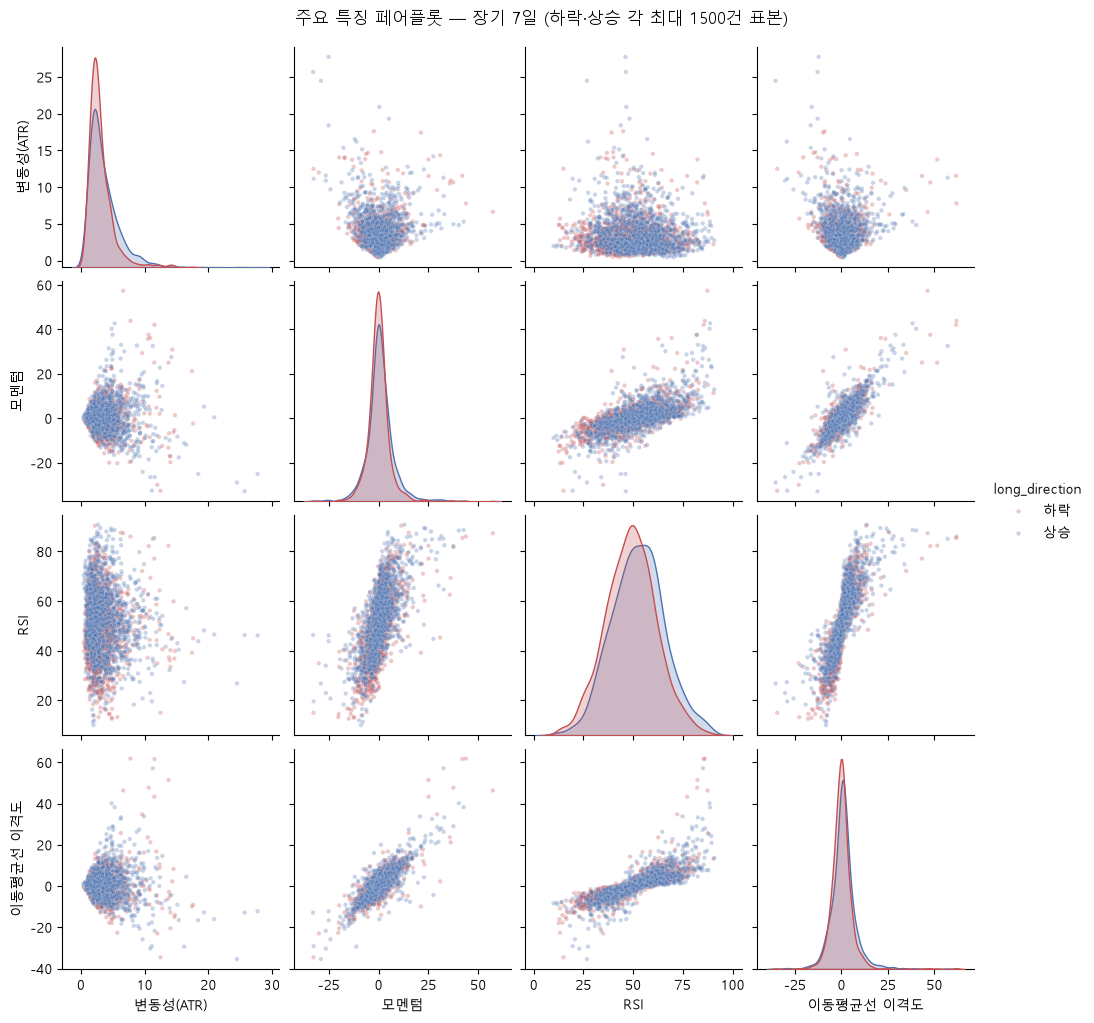

In [20]:
pair_source_long = clean[clean["long_direction"].isin(["하락", "상승"])]
pair_sample_long = pd.concat([
    grp.sample(min(len(grp), SAMPLE_PER_DIR), random_state=42)
    for _, grp in pair_source_long.groupby("long_direction", observed=True)
])
pair_df_long = pair_sample_long[PAIR_FEATURES + ["long_direction"]].rename(columns=FEATURE_LABELS_KO)

g2 = sns.pairplot(pair_df_long, hue="long_direction", hue_order=["하락", "상승"],
                   palette={"하락": "#C44E52", "상승": "#4C72B0"},
                   plot_kws={"alpha": 0.3, "s": 10}, diag_kind="kde")
g2.fig.suptitle(f"주요 특징 페어플롯 — 장기 7일 (하락·상승 각 최대 {SAMPLE_PER_DIR}건 표본)", y=1.02)
g2.savefig("fig9_pairplot_long.png", dpi=110)
plt.show()

**해석**: 단기(위)와 같은 방식으로 장기(7일) 기준 방향을 본다. 같은 특징 조합을 사용하여 단기에서와 달리 갈라진다면(또는 반대라면), 신호가 시계열에 따라 다르게 작동한다는 뜻이다.

결과적으로 장기는 단기보다 상관계수가 조금 더 큰 편이다 — 특히 모멘텀(장기 상승 그룹 r=0.073, p<0.001)과 RSI(장기 상승 그룹 r=0.121, p<0.001)가 단기보다 뚜렷해졌다. 그래도 r이 여전히 0.15를 넘지 않아, 페어플롯에서 하락·상승이 완전히 분리된 군집으로 나타나지는 않는다. 다만 단기 페어플롯보다는 모멘텀-RSI, 모멘텀-변동성 조합에서 상승 방향(파랑) 점들이 우상귀 쪽으로 조금 더 몰리는 경향이 눈에 띈다 — 5-4에서 확인한 장기일수록 모멘텀·RSI가 상승과 약하게 연관된다는 패턴과 일치한다.

## 8. 결론

**시사점**:
- 변동성은 방향과 무관하게 큰 변동 자체를 예고하는 신호였다 — 하락·상승 비교에서 이 비대칭성 부재가 더 명확하게 드러났고, 5-4에서 그룹을 나누어 봐도 이 패턴은 유지됐다.
- 나머지 시장 특징은 방향·크기 어느 쪽에도 크게 뚜렷한 신호를 주지 못했다.
- 시간대(UTC) 및 평일/주말에 따른 방향성 편향은 통계적으로 없었다.
- 뉴스 보도량·논조 역시 가격의 방향과 변동 폭 어느 쪽과도 의미 있는 관계를 보이지 않았다.
- 코인 종목마다 변동성 편차가 컸으며, 표본 크기가 크다 보니 아주 작은 상관관계도 유의미하게 나오는 경우가 많았다. 하여, 본 분석 전반에서는 p-value 자체보다 r의 절댓값·중앙값 차이의 크기를 신호의 실질적 중요도 판단 기준으로 삼았다.

**한계**:
- GDELT는 전세계 매체를 다루지만 검색어(예: "solana")가 종목이 아닌 동명이의어를 일부 포함할 수 있다.
- 시세(4시간)와 뉴스(일 단위)의 그레인 차이 때문에, D일 뉴스는 D+1일의 첫 4시간봉을 대표값으로 삼아 결합하였고, 더 세밀한 시간 단위로 시장 반응이 있을 수 있다.
- 방향별 상관계수(5-4, 6-1)는 변동 폭 분위수로 나눈 그룹 내부에서 계산하므로 범위가 좁아 상관계수 절대값 자체가 작게 나오기 쉬우므로, 그룹 간 상대 비교 위주로 해석해야 한다.
- 표본 크기가 크다 보니 아주 작은 상관관계도 유의미하게 나오는 경우가 많아, 본 분석 전반에서는 p-value 자체보다 r의 절댓값·중앙값 차이의 크기를 신호의 실질적 중요도로 보아야 한다.
- 상관계수가 낮다는 것이 전조 신호가 절대 없다는 증명은 아니며, 비선형 패턴이나 여기서 다루지 않은 다른 지표(온체인 데이터, 파생상품 시장 지표 등)에는 더 강한 신호가 있을 수 있다.
- 실제 매매 전략 구현 시, 이번 상관관계 분석에 더해 신호 발생 이후의 실현 수익률을 시뮬레이션하는 별도 백테스트가 필요하다.

**데이터 출처**: Binance 공개 API(시세), GDELT Project BigQuery 공개 데이터셋 `gdelt-bq.gdeltv2.gkg`(뉴스 보도량·논조). 수집 일시(anchor): 2026-07-23.